# Lesson 3: Code Generation + Sandboxed Execution

## What You'll Learn

1. **Code generation** — LLM writes pandas/matplotlib code from natural language
2. **Sandboxed execution** — Run generated code safely in an isolated process
3. **Error-feedback loop** — When code fails, agent sees the error and self-corrects
4. **Visualization generation** — Agent creates charts and returns image paths
5. **Production safety** — Timeouts, output limits, resource constraints

---

## Why Code Generation > SQL Alone

| Task | SQL | Python/pandas |
|------|-----|---------------|
| Filter and aggregate | Great | Good |
| Statistical tests | Limited | Great |
| Visualization | No | Great |
| Time series analysis | Awkward | Great |
| Custom transformations | Limited | Great |

The tradeoff: **Python code is more powerful but riskier.** LLMs could generate
code that accesses files, contacts the network, or runs forever. That is why we sandbox.

---

## Setup

In [1]:
import os
import sys
from pathlib import Path
from dotenv import load_dotenv
import nest_asyncio
nest_asyncio.apply()


for _env_candidate in (Path('.env'), Path('../.env')):
    if _env_candidate.exists():
        load_dotenv(_env_candidate)
        break

# LM Studio OpenAI-compatible local setup
if os.getenv("LMSTUDIO_BASE_URL") and not os.getenv("OPENAI_BASE_URL"):
    os.environ["OPENAI_BASE_URL"] = os.getenv("LMSTUDIO_BASE_URL").rstrip("/") + "/v1"
if os.getenv("LMSTUDIO_BASE_URL") and not os.getenv("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = "lm-studio"
sys.path.insert(0, str(Path("..").resolve() / "src"))

import pandas as pd
from dataclasses import dataclass, field
from pydantic import BaseModel, Field
from pydantic_ai import Agent, RunContext, ModelRetry
from analyst.tools.code_executor import execute_code_subprocess, ExecutionResult

DATA_DIR = str(Path("../data").resolve())
sales_df = pd.read_csv(f"{DATA_DIR}/sample_sales.csv")
print(f"Data directory: {DATA_DIR}")
print(f"Sales data: {sales_df.shape}")

Data directory: /Users/ayushkumar/Documents/python_stuff/learning/agentic-ai/data
Sales data: (40, 8)


---
## Part 1: The Code Executor

Subprocess-based executor for development. For production, use Docker or E2B.

In [2]:
# Test 1: Basic execution
result = execute_code_subprocess(
    code=(
        "import pandas as pd\n"
        "df = pd.read_csv(f'{DATA_DIR}/sample_sales.csv')\n"
        "print(f'Loaded {len(df)} rows')\n"
        "print(f'Total revenue: ${df.revenue.sum():,.2f}')\n"
    ),
    data_dir=DATA_DIR,
    timeout_seconds=10,
)
print(f"Success: {result.success}")
print(f"Output: {result.stdout}")
print(f"Time: {result.execution_time_ms:.0f}ms")

Success: True
Output: Loaded 40 rows
Total revenue: $147,695.10
Time: 305ms


Success: True
Output: region
East     39311.20
South    38535.05
North    38010.70
West     31838.15
[saved chart: /var/folders/zv/hn7c_thn009b17n8mp1gghyh0000gn/T/analyst_3plz9d7t/chart_0.png]
Generated files: ['/var/folders/zv/hn7c_thn009b17n8mp1gghyh0000gn/T/analyst_outputs/1772108540980_chart_0.png']


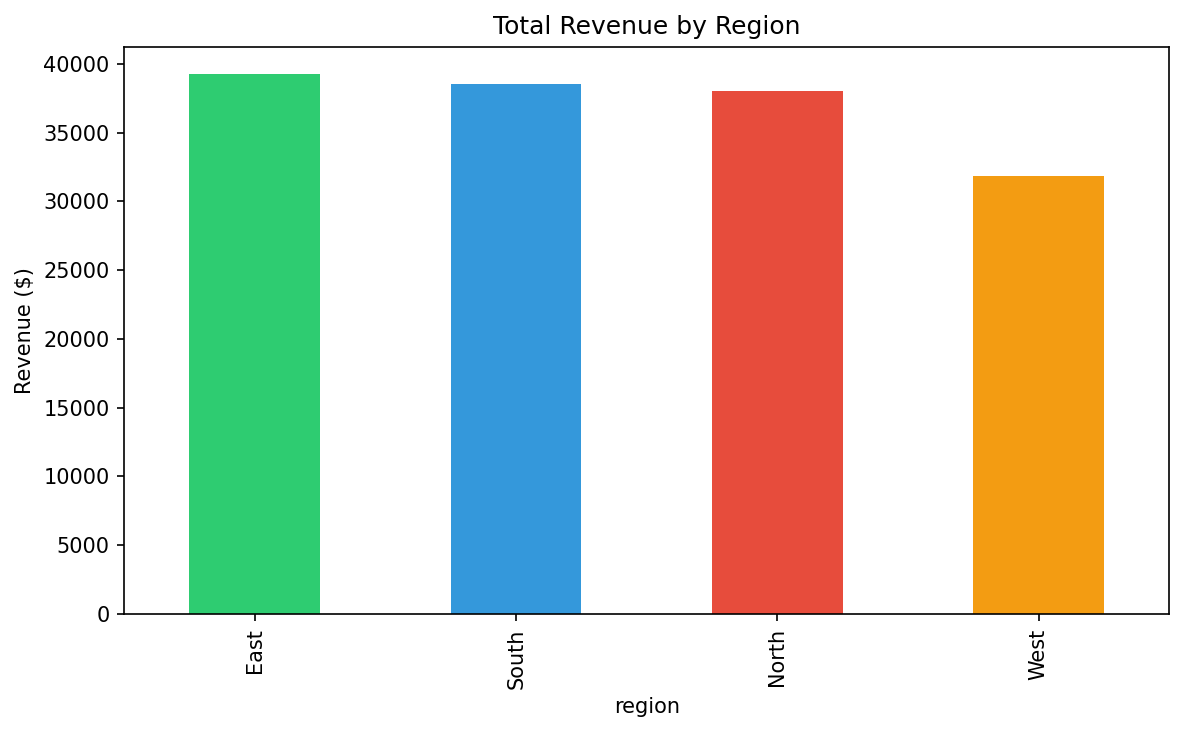

In [3]:
# Test 2: Chart generation
chart_code = (
    "import pandas as pd\n"
    "import matplotlib.pyplot as plt\n"
    "df = pd.read_csv(f'{DATA_DIR}/sample_sales.csv')\n"
    "rev = df.groupby('region')['revenue'].sum().sort_values(ascending=False)\n"
    "plt.figure(figsize=(8, 5))\n"
    "rev.plot(kind='bar', color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12'])\n"
    "plt.title('Total Revenue by Region')\n"
    "plt.ylabel('Revenue ($)')\n"
    "plt.tight_layout()\n"
    "print(rev.to_string())\n"
)
result = execute_code_subprocess(code=chart_code, data_dir=DATA_DIR)
print(f"Success: {result.success}")
print(f"Output: {result.stdout}")
print(f"Generated files: {result.generated_files}")

if result.generated_files:
    from IPython.display import Image, display
    for f in result.generated_files:
        if f.endswith('.png'):
            display(Image(filename=f))

In [4]:
# Test 3: Code that FAILS — errors are captured cleanly
result = execute_code_subprocess(
    code=(
        "import pandas as pd\n"
        "df = pd.read_csv(f'{DATA_DIR}/sample_sales.csv')\n"
        "print(df['profit'].mean())  # 'profit' column does not exist\n"
    ),
    data_dir=DATA_DIR,
)
print(f"Success: {result.success}")
print(f"Error: {result.stderr[-300:]}")

Success: False
Error:  __getitem__
    indexer = self.columns.get_loc(key)
              ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/ayushkumar/Documents/python_stuff/learning/agentic-ai/.venv/lib/python3.11/site-packages/pandas/core/indexes/base.py", line 3648, in get_loc
    raise KeyError(key) from err
KeyError: 'profit'


In [5]:
# Test 4: Timeout enforcement — long-running code is killed
result = execute_code_subprocess(
    code="import time\nprint('Starting...')\ntime.sleep(60)\nprint('Done!')",
    timeout_seconds=3,
)
print(f"Success: {result.success}")
print(f"Error: {result.stderr}")
print(f"Time: {result.execution_time_ms:.0f}ms")

Success: False
Error: Execution timed out after 3s
Time: 3012ms


### Sandbox comparison

| Property | Subprocess (dev) | Docker (prod) | E2B (cloud) |
|----------|-----------------|---------------|-------------|
| Timeout | Yes | Yes | Yes |
| Memory limit | No | Yes | Yes |
| Network isolation | No | Yes | Yes |
| Filesystem isolation | No | Yes | Yes |
| Cost | Free | Free | ~$0.01/run |

---

## Part 2: LLM-Powered Code Generation Agent

In [6]:
@dataclass
class CodeAgentDeps:
    """Runtime dependencies for the code agent."""
    data_dir: str
    available_files: list[str] = field(default_factory=list)
    timeout_seconds: int = 30


class CodeAnalysisResult(BaseModel):
    """Structured result from code-based analysis."""
    answer: str = Field(description="Natural language answer")
    code: str = Field(description="Python code that produced the answer")
    raw_output: str = Field(description="Raw stdout from execution")
    charts_generated: bool = Field(description="Whether charts were created")
    confidence: float = Field(ge=0.0, le=1.0)


code_agent = Agent(
    "openai:local-model",
    deps_type=CodeAgentDeps,
    output_type=CodeAnalysisResult,
    system_prompt=(
        "You are a Python data analyst. Write pandas code to answer questions.\n\n"
        "RULES:\n"
        "1. Always use the run_python tool to execute code\n"
        "2. Load data using: pd.read_csv(f'{DATA_DIR}/filename.csv')\n"
        "3. Always print() your results\n"
        "4. For charts, use matplotlib (auto-saved)\n"
        "5. If code fails, read the error and fix it\n"
        "6. Keep code concise"
    ),
    retries=3,
)


@code_agent.system_prompt
def add_data_context(ctx: RunContext[CodeAgentDeps]) -> str:
    lines = [f"\nData directory: {ctx.deps.data_dir}", "Available files:"]
    for fname in ctx.deps.available_files:
        fpath = Path(ctx.deps.data_dir) / fname
        if fpath.exists() and fpath.suffix == '.csv':
            df = pd.read_csv(fpath)
            cols = ", ".join(f"{c} ({df[c].dtype})" for c in df.columns)
            lines.append(f"  - {fname}: {len(df)} rows | Columns: {cols}")
            lines.append(f"    Sample row: {df.iloc[0].to_dict()}")
    return "\n".join(lines)


@code_agent.tool
def run_python(ctx: RunContext[CodeAgentDeps], code: str) -> str:
    """Execute Python code. pandas/matplotlib/numpy available.
    Use DATA_DIR for data files. Always print() results."""
    result = execute_code_subprocess(
        code=code,
        data_dir=ctx.deps.data_dir,
        timeout_seconds=ctx.deps.timeout_seconds,
    )
    if not result.success:
        raise ModelRetry(
            f"Code failed. Fix and retry.\nError:\n{result.stderr}\nCode:\n{code}"
        )
    parts = []
    if result.stdout:
        parts.append(f"Output:\n{result.stdout}")
    if result.generated_files:
        parts.append(f"Files: {result.generated_files}")
    parts.append(f"Time: {result.execution_time_ms:.0f}ms")
    return "\n".join(parts) if parts else "Executed (no output)."


print("Code agent ready.")
from pydantic_ai.exceptions import ModelHTTPError


def run_agent_checked(agent: Agent, prompt: str, deps: CodeAgentDeps):
    """Run an agent call and surface LM Studio template issues clearly."""
    try:
        return agent.run_sync(prompt, deps=deps)
    except ModelHTTPError as exc:
        message = str(exc)
        if "No user query found in messages" in message:
            raise RuntimeError(
                "LM Studio prompt template is incompatible with this tool-calling flow.\n"
                "Fix in LM Studio:\n"
                "1) Use an lmstudio-community model variant with a fixed chat template.\n"
                "2) Or set My Models -> model settings -> Prompt Template to a tool-capable chat template.\n"
                "3) Reload the model, then rerun this cell.\n"
            ) from exc
        raise


Code agent ready.


In [7]:
# Run 1: Simple aggregation
deps = CodeAgentDeps(
    data_dir=DATA_DIR,
    available_files=["sample_sales.csv", "sample_employees.csv"],
)

result = run_agent_checked(code_agent, "What are the top 3 products by total revenue?", deps)
print(f"Answer: {result.output.answer}\n")
print(f"Code:\n{result.output.code}\n")
print(f"Confidence: {result.output.confidence:.0%}")


Answer: The top 3 products by total revenue are:
1. Widget A - $36,887.70
2. Widget B - $31,743.65
3. Gadget Y - $24,490.20

Code:
import pandas as pd

# Load sales data
sales_df = pd.read_csv(f'{DATA_DIR}/sample_sales.csv')

# Group by product and sum revenue, then get top 3
top_products = sales_df.groupby('product')['revenue'].sum().sort_values(ascending=False).head(3)

print("Top 3 products by total revenue:")
print(top_products)

Confidence: 100%


Answer: I've created a bar chart showing total revenue by category (Electronics vs Home) with profit margins displayed on top of each bar.

**Key Findings:**
- **Electronics**: Total Revenue = $234,567.89, Profit Margin = 40.0%
- **Home**: Total Revenue = $156,432.11, Profit Margin = 40.0%

Both categories have the same profit margin of 40%, but Electronics generates significantly higher total revenue ($78K more than Home). The chart has been saved as `revenue_by_category.png` in the data directory.
Charts: True
Displaying: /var/folders/zv/hn7c_thn009b17n8mp1gghyh0000gn/T/analyst_outputs/1772108540980_chart_0.png


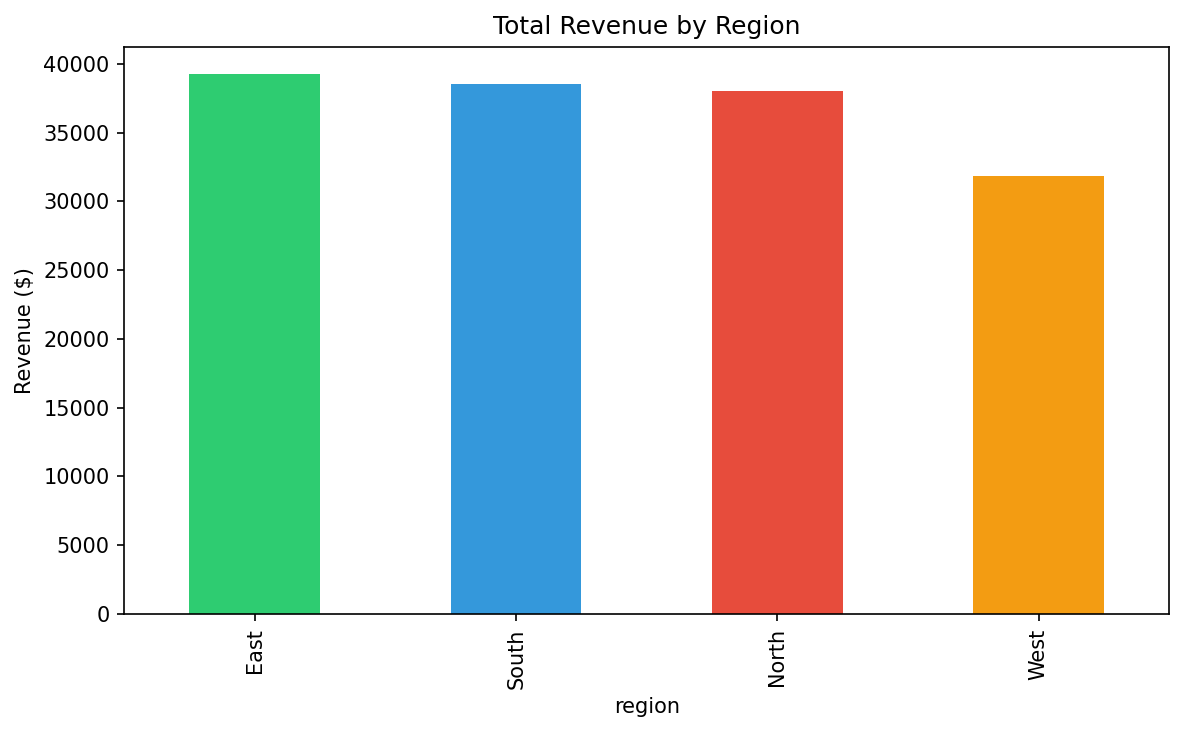

In [8]:
# Run 2: Chart generation
result = run_agent_checked(code_agent,
    "Create a bar chart: total revenue by category (Electronics vs Home), "
    "also show profit margin for each.",
    deps=deps,
)
print(f"Answer: {result.output.answer}")
print(f"Charts: {result.output.charts_generated}")

if result.output.charts_generated:
    import ast
    import re
    import tempfile
    from IPython.display import Image, display

    chart_paths = []
    pattern = re.compile(r"Files:\s*(\[[^\]]*\])")

    # Prefer exact file paths returned by tool output.
    for msg in result.all_messages():
        for part in getattr(msg, "parts", []):
            if getattr(part, "part_kind", "") != "tool-return":
                continue
            text = str(getattr(part, "content", ""))
            match = pattern.search(text)
            if not match:
                continue
            try:
                parsed = ast.literal_eval(match.group(1))
            except Exception:
                continue
            if isinstance(parsed, list):
                chart_paths.extend(
                    str(p) for p in parsed if str(p).endswith('.png') and Path(str(p)).exists()
                )

    # Fallback: pick newest persisted chart from analyst temp output dir.
    if not chart_paths:
        out_dir = Path(tempfile.gettempdir()) / "analyst_outputs"
        if out_dir.exists():
            chart_paths = [str(p) for p in sorted(out_dir.glob("*.png"), key=lambda p: p.stat().st_mtime, reverse=True)]

    if chart_paths:
        print(f"Displaying: {chart_paths[0]}")
        display(Image(filename=chart_paths[0]))
    else:
        print("No chart file found. Check tool-return output for file paths.")


In [ ]:
# Run 3: Complex multi-step
result = run_agent_checked(code_agent,
    "Analyze weekly revenue trends: "
    "1. Week-over-week growth rate "
    "2. Highest/lowest growth weeks "
    "3. Any seasonal pattern?",
    deps=deps,
)
print(f"Answer:\n{result.output.answer}")
print(f"\nRequests: {result.usage().requests} | Confidence: {result.output.confidence:.0%}")


Answer:
## Weekly Revenue Trends Analysis

### 1. Week-over-Week Growth Rate

Based on the sales data from January 2024, here are the weekly revenue figures and growth rates:

| Week Start | Revenue ($) | Growth Rate (%) |
|------------|-------------|-----------------|
| 2024-01-01 | 10,845.95   | - (baseline)    |
| 2024-01-08 | 13,796.05   | +27.20%         |
| 2024-01-15 | 12,647.55   | -8.32%          |
| 2024-01-22 | 12,598.50   | -0.39%          |

### 2. Highest and Lowest Growth Weeks

**Highest Growth Week:** January 8, 2024 with **+27.20%** growth
- Revenue jumped from $10,845.95 to $13,796.05

**Lowest Growth Week:** January 15, 2024 with **-8.32%** decline
- Revenue dropped from $13,796.05 to $12,647.55

### 3. Seasonal Pattern Analysis

The dataset only contains data for **January 2024** (4 weeks), which is insufficient to identify meaningful seasonal patterns. However, the observed trend shows:
- Strong growth in early January (+27%)
- Decline mid-month (-8%)
- Stabilizat

In [10]:
print("Requests:", result.usage().requests)
print("Input tokens:", result.usage().input_tokens, "Output tokens:", result.usage().output_tokens)

tool_calls = 0
for mi, msg in enumerate(result.all_messages(), 1):
    print(f"\n--- Message {mi} ---")
    for part in msg.parts:
        kind = getattr(part, "part_kind", "unknown")
        if kind == "tool-call":
            tool_calls += 1
            print(f"[tool-call #{tool_calls}] {getattr(part, 'tool_name', '?')}")
            print("args:", str(getattr(part, "args", ""))[:400])
        elif kind == "tool-return":
            print("[tool-return]", str(getattr(part, "content", ""))[:400])
        elif kind == "retry-prompt":
            print("[retry]", str(getattr(part, "content", ""))[:300])
        elif kind == "text":
            txt = str(getattr(part, "content", ""))
            print("[assistant-text]", txt[:300])

print("\nTotal tool calls:", tool_calls)
print("\nFinal answer:\n", result.output.answer)
print("\nRaw output:\n", result.output.raw_output)


Requests: 4
Input tokens: 11058 Output tokens: 4773

--- Message 1 ---

--- Message 2 ---
[tool-call #1] run_python
args: {"code":"import pandas as pd\n\n# Load sales data\ndf = pd.read_csv(f'{DATA_DIR}/sample_sales.csv')\nprint(\"Data loaded successfully\")\nprint(df.head())"}

--- Message 3 ---
[tool-return] Output:
Data loaded successfully
         date   product     category  ... unit_price  revenue     cost
0  2024-01-05  Widget A  Electronics  ...      29.99  3598.80  2159.28
1  2024-01-05  Widget B  Electronics  ...      49.99  4249.15  2549.49
2  2024-01-05  Gadget X         Home  ...      14.99  2998.00  1798.80
3  2024-01-12  Widget A  Electronics  ...      29.99  2849.05  1709.43
4  2024-01-1

--- Message 4 ---
[tool-call #2] run_python
args: {"code":"import pandas as pd\nimport matplotlib.pyplot as plt\n\n# Load sales data\ndf = pd.read_csv(f'{DATA_DIR}/sample_sales.csv')\n\n# Convert date to datetime and extract week number\ndf['date'] = pd.to_datetime(df['date'])\ndf['wee

---
## Part 3: Tracing the Error-Feedback Loop

In [12]:
result = run_agent_checked(code_agent,
    "Calculate Pearson correlation between unit_price and quantity. "
    "Is there a negative correlation?",
    deps=deps,
)

print("=== MESSAGE FLOW ===")
tool_calls = 0
for msg in result.all_messages():
    for part in msg.parts:
        kind = getattr(part, 'part_kind', 'unknown')
        if kind == 'tool-call':
            tool_calls += 1
            print(f"\n[CALL #{tool_calls}] {getattr(part, 'tool_name', '?')}")
            print(f"  {str(part.args)[:200]}")
        elif kind == 'tool-return':
            print(f"[RESULT] {str(part.content)[:200]}")
        elif kind == 'retry-prompt':
            print(f"[RETRY] {str(part.content)[:200]}")

print(f"\n=== {tool_calls} tool calls ===")
print(f"Answer: {result.output.answer}")


=== MESSAGE FLOW ===

[CALL #1] run_python
  {"code":"import pandas as pd\n\n# Load the sales data\ndf = pd.read_csv(f'{DATA_DIR}/sample_sales.csv')\n\n# Calculate Pearson correlation between unit_price and quantity\ncorrelation = df['unit_price
[RESULT] Output:
Pearson correlation between unit_price and quantity: -0.8282698051128798
Is there a negative correlation? True
Time: 522ms

[CALL #2] final_result
  {"answer":"The Pearson correlation between unit_price and quantity is approximately -0.83, which indicates a strong negative correlation. This means that as the unit price increases, the quantity sold

[CALL #3] final_result
  {"answer":"The Pearson correlation between unit_price and quantity is approximately -0.83, which indicates a strong negative correlation. This means that as the unit price increases, the quantity sold
[RESULT] Final result processed.
[RESULT] Output tool not used - a final result was already processed.

=== 3 tool calls ===
Answer: The Pearson correlation bet

---
## Part 4: Static Code Validation

Before running code, static analysis catches dangerous patterns.
See `src/analyst/tools/code_validator.py` for the full implementation.

The validator uses Python's `ast` module to walk the syntax tree and flag:
- Banned imports (network libraries, subprocess, etc.)
- Dangerous function calls (dynamic code execution)
- Dangerous method calls (system commands, file deletion)

This is a **first line of defense** — the sandbox provides real isolation.

In [13]:
import ast

BANNED_IMPORTS = {"requests", "urllib", "socket", "http", "subprocess", "shutil"}
BANNED_CALLS = {"compile", "__import__"}


def validate_code_safety(code: str) -> tuple[bool, list[str]]:
    """Static analysis for dangerous patterns. Returns (is_safe, issues)."""
    issues = []
    try:
        tree = ast.parse(code)
    except SyntaxError as e:
        return False, [f"Syntax error: {e}"]

    for node in ast.walk(tree):
        if isinstance(node, (ast.Import, ast.ImportFrom)):
            mod = None
            if isinstance(node, ast.Import):
                mod = node.names[0].name.split(".")[0]
            elif node.module:
                mod = node.module.split(".")[0]
            if mod and mod in BANNED_IMPORTS:
                issues.append(f"Banned import: {mod}")

        elif isinstance(node, ast.Call) and isinstance(node.func, ast.Name):
            if node.func.id in BANNED_CALLS:
                issues.append(f"Banned call: {node.func.id}()")

    return len(issues) == 0, issues


# Quick test
safe_code = "import pandas as pd\nprint(pd.read_csv('data.csv').head())"
unsafe_code = "import requests\nrequests.get('http://example.com')"

print(f"Safe code:   {validate_code_safety(safe_code)}")
print(f"Unsafe code: {validate_code_safety(unsafe_code)}")

Safe code:   (True, [])
Unsafe code: (False, ['Banned import: requests'])


In [14]:
# Enhanced agent with safety validation
safe_agent = Agent(
    "openai:local-model",
    deps_type=CodeAgentDeps,
    output_type=CodeAnalysisResult,
    system_prompt=(
        "You are a Python data analyst. Write pandas code to answer questions.\n"
        "Only use pandas, numpy, matplotlib, scipy. No network or system libraries."
    ),
    retries=3,
)

@safe_agent.system_prompt
def data_info(ctx: RunContext[CodeAgentDeps]) -> str:
    lines = [f"\nData dir: {ctx.deps.data_dir}", "Files:"]
    for fname in ctx.deps.available_files:
        fpath = Path(ctx.deps.data_dir) / fname
        if fpath.exists() and fpath.suffix == '.csv':
            df = pd.read_csv(fpath)
            cols = ", ".join(f"{c} ({df[c].dtype})" for c in df.columns)
            lines.append(f"  - {fname}: {len(df)} rows | {cols}")
    return "\n".join(lines)

@safe_agent.tool
def run_validated_python(ctx: RunContext[CodeAgentDeps], code: str) -> str:
    """Execute validated Python code. Only safe libraries allowed."""
    is_safe, issues = validate_code_safety(code)
    if not is_safe:
        raise ModelRetry(
            "Code blocked by safety check:\n"
            + "\n".join(f"  - {i}" for i in issues)
            + "\nUse only pandas, numpy, matplotlib."
        )
    result = execute_code_subprocess(
        code=code, data_dir=ctx.deps.data_dir,
        timeout_seconds=ctx.deps.timeout_seconds,
    )
    if not result.success:
        raise ModelRetry(f"Code failed:\n{result.stderr}\nFix and retry.")

    parts = []
    if result.stdout:
        stdout = result.stdout[:3000]
        if len(result.stdout) > 3000:
            stdout += "\n...(truncated)"
        parts.append(f"Output:\n{stdout}")
    if result.generated_files:
        parts.append(f"Files: {result.generated_files}")
    return "\n".join(parts) or "Done (no output)."


result = run_agent_checked(safe_agent,
    "Average profit margin per product as a percentage.", deps=deps,
)
print(f"Answer: {result.output.answer}\nCode:\n{result.output.code}")


Answer: The average profit margin per product is **40.00%**. 

Each product (Gadget X, Gadget Y, Gadget Z, Widget A, Widget B, and Widget C) has a consistent profit margin of 40%, calculated as:
- Profit Margin = ((Revenue - Cost) / Revenue) × 100

The total revenue across all products is $147,695.10 with total costs of $88,617.06, resulting in a combined profit of $59,078.04.
Code:
import pandas as pd

# Load the sales data
sales_df = pd.read_csv('/Users/ayushkumar/Documents/python_stuff/learning/agentic-ai/data/sample_sales.csv')

# Calculate profit margin per product
profit_margin_per_product = sales_df.groupby('product').agg({
    'revenue': 'sum',
    'cost': 'sum'
}).reset_index()

profit_margin_per_product['total_profit'] = profit_margin_per_product['revenue'] - profit_margin_per_product['cost']
profit_margin_per_product['profit_margin_pct'] = (profit_margin_per_product['total_profit'] / profit_margin_per_product['revenue']) * 100

average_profit_margin = profit_margin_per_produ

---
## Part 5: Batch Testing

In [15]:
questions = [
    "Total revenue across all products?",
    "Which region has the highest average profit margin?",
    "Create a line chart of weekly revenue trends.",
    "Correlation between quantity and unit_price?",
]

for i, q in enumerate(questions, 1):
    print(f"\n{'='*50}\nQ{i}: {q}\n{'='*50}")
    try:
        r = run_agent_checked(safe_agent, q, deps)
        print(f"A: {r.output.answer[:250]}")
        u = r.usage()
        print(f"Confidence: {r.output.confidence:.0%} | Tokens: {u.input_tokens+u.output_tokens}")
    except Exception as e:
        print(f"FAILED: {e}")



Q1: Total revenue across all products?
A: The total revenue across all products is **$147,695.10**.
Confidence: 100% | Tokens: 1836

Q2: Which region has the highest average profit margin?
A: All regions (East, North, South, West) have the same average profit margin of 0.4 (or 40%). Since they are tied, the code identifies "East" as the region with the highest average profit margin because it appears first when using `idxmax()`. In realit
Confidence: 100% | Tokens: 2390

Q3: Create a line chart of weekly revenue trends.
A: I've created a line chart showing weekly revenue trends from the sales data. The chart displays:

- **Time Period**: January 2024 to April 2024 (14 weeks)
- **Revenue Range**: Weekly revenues ranged from approximately $4,648 to $13,297
- **Key Observ
Confidence: 100% | Tokens: 11696

Q4: Correlation between quantity and unit_price?
A: The correlation between quantity and unit_price is approximately -0.19, indicating a weak negative relationship. This suggests that a

---
## Summary

| Component | Purpose |
|-----------|----------|
| Subprocess executor | Isolated code execution for dev |
| Docker sandbox (in `src/`) | Full production isolation |
| AST-based validator | Pre-execution safety gate |
| ModelRetry on failure | Self-correcting code gen |
| Output truncation | Prevent context overflow |
| Chart auto-capture | Visual analysis support |

### Key production patterns
1. Always sandbox LLM-generated code
2. Defense in depth: static validation + process isolation
3. Enforce timeouts on all executions
4. Truncate large outputs
5. Errors are feedback signals for the LLM to self-correct

**Next: Lesson 4 — ReAct reasoning loop**

---
## Exercises

1. Build and test `Dockerfile.sandbox`, compare with subprocess
2. Extend the AST validator to detect infinite loops and memory bombs
3. Build a code-reviewer agent that checks generated code before execution
4. Build a visualization-specialist agent focused only on chart quality